Connected to Python 3.12.1

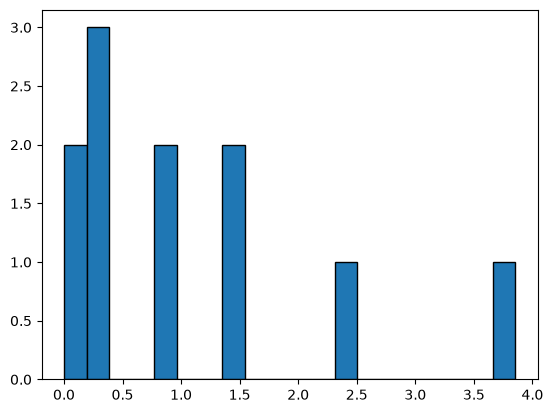

([1.7034821425277238, -1.2697714972513214, 0.07382815683095764, -2.2189099696830605, -0.6255839762177849, -0.64768433960874, -1.317522261855277, -1.7486794550962654, 0.2619515843499811, 2.7758661196829153, -0.6844267191226252], [1.450925704955422, 0.8061598276159313, 0.002725298370528239, 2.4617807267794403, 0.19567765565022704, 0.20974750188720478, 0.8679324552421227, 1.528939918337886, 0.034309316271732636, 3.8527163572017424, 0.23421996692448044])
0.007519959358652052


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the variables to be used
m = 1 
L = 100
eps = 0.1
k = 1

# Define the potental
def V(x,k):
    '''
    Given x, compute the potential
    '''
    return 0.5*k*x**2 

# Define the Hamiltonian function
def H(x,p):
    '''
    Given x,p, and V(x),compute the Hamiltonian
    '''
    return V(x,k) + 0.5*p**2/m
 
def test_normal_p(n,m):
    '''
    Before running the HMC algorithm, it is sensible to check that genrating p values from a normal distribution gives a correct kinetic energy distribution.
    We generate n p samples taken from a normal distribution, compute corresponding kinetic energies, and plot them to find the distribution.  
    '''
    # Initialise the p_normals and KE lists
    p_normals = []
    KE_p = []
    # Loop over n
    for t in range(n+1):
        # Generate the p values from the normal distribution
        p = np.random.normal(0, m**0.5)
        # Calculate the corresponding KE
        KE = 0.5*p**2/m
        # Append to the lists
        p_normals.append(p)
        KE_p.append(KE)
    # Plot
    plt.figure()
    plt.hist(KE_p, bins = 20, edgecolor = 'black')
    plt.show()
    return p_normals, KE_p
print(test_normal_p(10,m))

def HMC(n,L,eps):
    '''
    Carry out the HMC algorithm using the leafrog method to generate x values. 
    Simultaenously compute and story KE, PE, exp(-delH).
    '''
    # Initialise the x values
    x = [0]
    # Start the loop to generate the x values
    for t in range(n+1):
        # Draw the momentum from a Normal distribution
        p = np.random.normal(0,m**0.5)
        # Carry out step 1 of the leapfrog method
        p_star = p - 0.5*eps*k*x[t]
        x_star = x[t] + eps*p_star/m
        # Compute (x*,p*) using L leapfrog steps of size eps
        for l in range(1, L):
            p_star = p_star - eps*k*x_star
            x_star = x_star + eps*p_star/m
        # Carry out the final step of the leapfrog method
        p_star = p_star - 0.5*eps*k*x_star
        # Compute the acceptance ratio
        r = np.exp(-H(x_star, p_star) + H(x[t],p))
        # Draw W from a Uniform distribution
        W = np.random.uniform(0,1)
        # Carry out the Metropolis test
        if W <= min(1,r):
            x.append(x_star)
        else:
            x.append(x[t])
        # Compute the KE term for this trajectory
        KE = 0.5*p_star**2/m
    return x

# Find the expected value of x
def exp_val(x):
    '''
    Given a list of x values, compute the expected value
    '''
    return np.mean(x)   

print(exp_val(HMC(1000,L,eps)))